# DEFINICION DE VARIABLES

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv("data_input.csv", index_col=0, parse_dates=True)
data_input=df
data_input.head()

,temp,Unidades,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,CodigoArticulo_940-001,CodigoArticulo_940-005,CodigoArticulo_940-010,CodigoArticulo_940-012,CodigoArticulo_940-015,CodigoArticulo_940-506,CodigoArticulo_940-508,CodigoArticulo_940-511,CodigoArticulo_940-515,CodigoArticulo_940-520,CodigoArticulo_940-525,CodigoArticulo_R130101001,conditions_Snow
fecha,,,,,,,,,,,,,,,,,,,
2021-01-03,2.50,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2021-01-17,0.01,1,6,2,5,5,0,1,0,0,0,0,0,0,0,0,0,0,5
2021-01-31,8.33,0,1,3,10,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-14,9.61,0,0,0,14,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-28,10.09,4,1,0,13,2,0,0,0,0,0,0,0,0,2,0,2,0,0


In [52]:
## Definicion de variables
y=data_input[["Unidades"]]
df_X=data_input.drop(columns=["Unidades"])
X=df_X

In [53]:
# Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
train_size = int(len(df) * 0.8)  # 80% de los datos
# División manteniendo el orden temporal
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


# MODELOS

## Benchmark

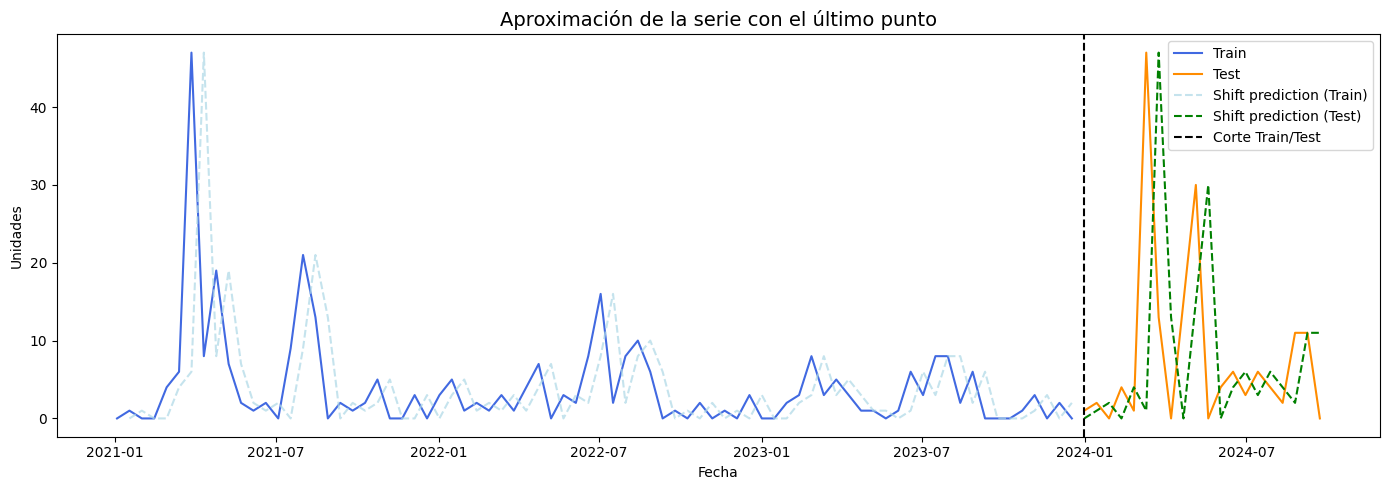

Rendimiento del modelo shift en datos de entrenamiento:
RMSE Train: 7.90
MSE Train: 62.44
MAE Train: 4.31
R² Train: -0.4730

Rendimiento del modelo shift en datos de prueba:
RMSE Test: 16.33
MSE Test: 266.79
MAE Test: 10.47
R² Test: -0.9860


In [54]:
# Crear la serie con predicciones usando shift(1)
y_shift_pred = data_input['Unidades'].shift(1)

# Visualizar todo junto
plt.figure(figsize=(14, 5))
plt.plot(df.index[:train_size], y_train, label='Train', color='royalblue')
plt.plot(df.index[train_size:], y_test, label='Test', color='darkorange')

# Añadir la predicción con shift (separando visual para train y test)
plt.plot(df.index[1:train_size], y_shift_pred[1:train_size], '--', color='lightblue', alpha=0.7, label='Shift prediction (Train)')
plt.plot(df.index[train_size:], y_shift_pred[train_size:], '--', color='green', label='Shift prediction (Test)')

plt.axvline(df.index[train_size], color='black', linestyle='--', label='Corte Train/Test')
plt.title("Aproximación de la serie con el último punto", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluar el rendimiento del modelo shift en los datos de prueba
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np



# Omitir el primer valor de train que sería NaN en la predicción
y_train_eval = y_train[1:]
y_train_pred_eval = y_shift_pred[:train_size][1:]

# Cálculo de métricas para el conjunto de entrenamiento
rmse_train = np.sqrt(mean_squared_error(y_train_eval, y_train_pred_eval))
mse_train = mean_squared_error(y_train_eval, y_train_pred_eval)
mae_train = mean_absolute_error(y_train_eval, y_train_pred_eval)
r2_train = r2_score(y_train_eval, y_train_pred_eval)

# Cálculo de métricas para el conjunto de prueba (manteniendo el ajuste que hiciste)
y_test_eval = y_test[1:]
y_pred_eval = y_shift_pred[train_size+1:]

rmse_test = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
mse_test = mean_squared_error(y_test_eval, y_pred_eval)
mae_test = mean_absolute_error(y_test_eval, y_pred_eval)
r2_test = r2_score(y_test_eval, y_pred_eval)

# Mostrar resultados
print(f"Rendimiento del modelo shift en datos de entrenamiento:")
print(f"RMSE Train: {rmse_train:.2f}")
print(f"MSE Train: {mse_train:.2f}")
print(f"MAE Train: {mae_train:.2f}")
print(f"R² Train: {r2_train:.4f}\n")

print(f"Rendimiento del modelo shift en datos de prueba:")
print(f"RMSE Test: {rmse_test:.2f}")
print(f"MSE Test: {mse_test:.2f}")
print(f"MAE Test: {mae_test:.2f}")
print(f"R² Test: {r2_test:.4f}")

In [55]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "BENCHMARK"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics1 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics1


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,BENCHMARK,62.441558,4.311688,7.901997,-0.473039,266.789474,10.473684,16.333691,-0.985958


## ARIMA

c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)


ARIMA - MÉTRICAS DE ENTRENAMIENTO:
MAE Train: 3.4461, MSE Train: 42.9236, RMSE Train: 3.0760, R² Train: -0.0208

ARIMA - MÉTRICAS DE PRUEBA:
MAE Test: 6.7549, MSE Test: 155.2542, RMSE Test: 3.0760, R² Test: -0.1924


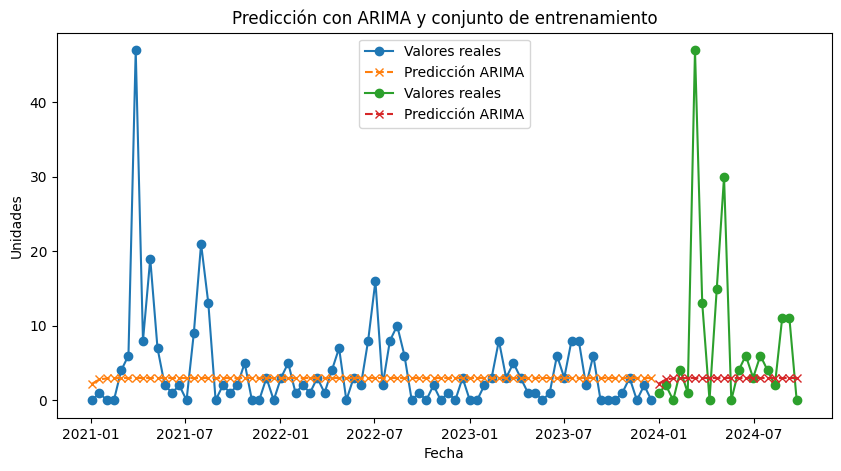

In [56]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir variables (suponiendo que 'df' tiene 'Fecha' como índice y 'Unidades_y' como la variable objetivo)
y = data_input["Unidades"]
df_X = data_input.drop(columns=["Unidades"])
X = df_X

# División en entrenamiento y prueba respetando la temporalidad
train_size = int(len(y) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Entrenar modelo ARIMA
p, d, q = 1, 1, 1  # Ajustar según análisis de ACF/PACF
modelo_arima = ARIMA(y_train, order=(p, d, q))
resultado_arima = modelo_arima.fit()


# Predicción
pred_arima_train = resultado_arima.forecast(steps=len(y_train))
pred_arima_test = resultado_arima.forecast(steps=len(y_test))

# Evaluación de métricas
mae_test= mean_absolute_error(y_test, pred_arima_test)
mse_test = mean_squared_error(y_test, pred_arima_test)
rmse_test = np.sqrt(mse)
r2_test = r2_score(y_test, pred_arima_test)
mae_train = mean_absolute_error(y_train, pred_arima_train)
mse_train = mean_squared_error(y_train, pred_arima_train)
rmse_train = np.sqrt(mse)
r2_train = r2_score(y_train, pred_arima_train)

print(f"ARIMA - MÉTRICAS DE ENTRENAMIENTO:\n"
      f"MAE Train: {mae_train:.4f}, MSE Train: {mse_train:.4f}, RMSE Train: {rmse_train:.4f}, R² Train: {r2_train:.4f}\n")

print(f"ARIMA - MÉTRICAS DE PRUEBA:\n"
      f"MAE Test: {mae_test:.4f}, MSE Test: {mse_test:.4f}, RMSE Test: {rmse_test:.4f}, R² Test: {r2_test:.4f}")

import matplotlib.pyplot as plt



# Gráficos ARIMA
plt.figure(figsize=(10, 5))
plt.plot(y_train.index, y_train, label="Valores reales", marker="o")
plt.plot(y_train.index, pred_arima_train, label="Predicción ARIMA", linestyle="dashed", marker="x")
plt.plot(y_test.index, y_test, label="Valores reales", marker="o")
plt.plot(y_test.index, pred_arima_test, label="Predicción ARIMA", linestyle="dashed", marker="x")
plt.legend()
plt.title("Predicción con ARIMA y conjunto de entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.show()


In [57]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "ARIMA"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics2 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics2


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,ARIMA,42.923606,3.446118,3.076026,-0.020808,155.254236,6.754875,3.076026,-0.192429


## ARIMAX

c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)


ARIMAX - MÉTRICAS DE ENTRENAMIENTO:
MAE Train: 1.8098, MSE Train: 9.8459, RMSE Train: 3.0760, R² Train: 0.7658

ARIMAX - MÉTRICAS DE PRUEBA:
MAE Test: 8.4198, MSE Test: 228.1806, RMSE Test: 3.0760, R² Test: -0.7525


c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


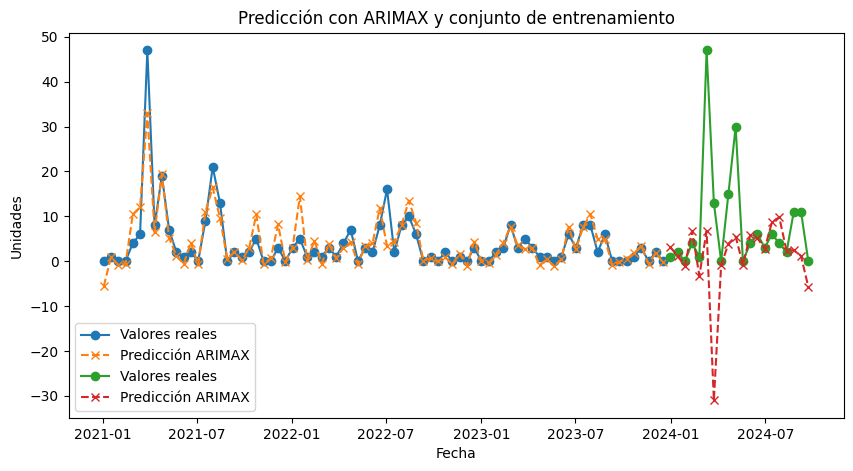

In [58]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir variables (X = características, y = variable objetivo)
y = data_input["Unidades"]
X = data_input.drop(columns=["Unidades"])  # Variables predictoras

# División en entrenamiento y prueba respetando la temporalidad
train_size = int(len(y) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Entrenar modelo ARIMAX (con variables externas X_train)
p, d, q = 1, 1, 1  # Ajustar según ACF/PACF
modelo_arimax = ARIMA(y_train, exog=X_train, order=(p, d, q))
resultado_arimax = modelo_arimax.fit()


# Predicción
pred_arimax_train = resultado_arimax.forecast(steps=len(y_train), exog=X_train)
pred_arimax_test = resultado_arimax.forecast(steps=len(y_test), exog=X_test)

# Evaluación de métricas
mae_test= mean_absolute_error(y_test, pred_arimax_test)
mse_test = mean_squared_error(y_test, pred_arimax_test)
rmse_test = np.sqrt(mse)
r2_test = r2_score(y_test, pred_arimax_test)
mae_train = mean_absolute_error(y_train, pred_arimax_train)
mse_train = mean_squared_error(y_train, pred_arimax_train)
rmse_train = np.sqrt(mse)
r2_train = r2_score(y_train, pred_arimax_train)

print(f"ARIMAX - MÉTRICAS DE ENTRENAMIENTO:\n"
      f"MAE Train: {mae_train:.4f}, MSE Train: {mse_train:.4f}, RMSE Train: {rmse_train:.4f}, R² Train: {r2_train:.4f}\n")

print(f"ARIMAX - MÉTRICAS DE PRUEBA:\n"
      f"MAE Test: {mae_test:.4f}, MSE Test: {mse_test:.4f}, RMSE Test: {rmse_test:.4f}, R² Test: {r2_test:.4f}")

import matplotlib.pyplot as plt



# Gráficos ARIMAX
plt.figure(figsize=(10, 5))
plt.plot(y_train.index, y_train, label="Valores reales", marker="o")
plt.plot(y_train.index, pred_arimax_train, label="Predicción ARIMAX", linestyle="dashed", marker="x")
plt.plot(y_test.index, y_test, label="Valores reales", marker="o")
plt.plot(y_test.index, pred_arimax_test, label="Predicción ARIMAX", linestyle="dashed", marker="x")
plt.legend()
plt.title("Predicción con ARIMAX y conjunto de entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.show()


In [59]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "ARIMAX"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics3 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics3


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,ARIMAX,9.845941,1.809847,3.076026,0.765844,228.180566,8.419796,3.076026,-0.752539


## SARIMA

c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA - MÉTRICAS DE ENTRENAMIENTO:
MAE Train: 5.2667, MSE Train: 57.1372, RMSE Train: 3.0760, R² Train: -0.3588

SARIMA - MÉTRICAS DE PRUEBA:
MAE Test: 7.5528, MSE Test: 186.3624, RMSE Test: 3.0760, R² Test: -0.4314


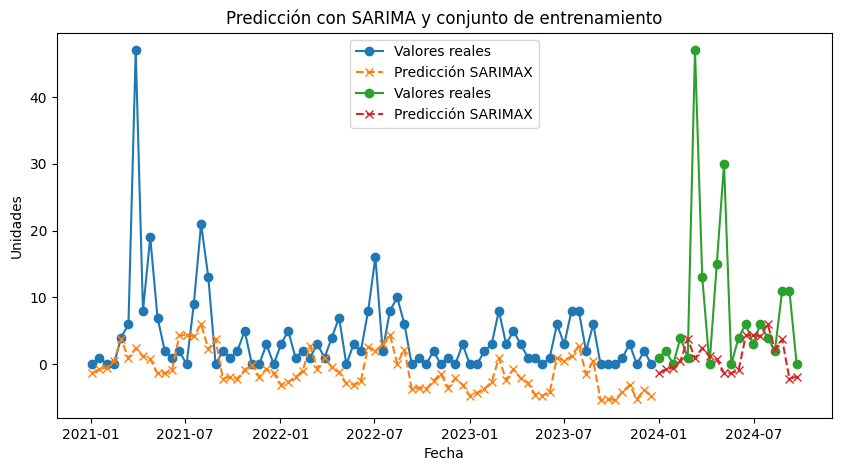

In [60]:
from statsmodels.tsa.statespace.sarimax import SARIMAX # S AR I MA
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir variables
y = data_input["Unidades"]  # Variable objetivo
train_size = int(len(y) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Configurar hiperparámetros SARIMA
p, d, q = 1, 1, 1  # ARIMA parámetros ## PROBAR CON 2,1,2
P, D, Q, s = 1, 1, 1, 26  # Estacionalidad (s=12 si hay patrón mensual)

# Entrenar modelo SARIMA
modelo_sarima = SARIMAX(y_train, order=(p, d, q), seasonal_order=(P, D, Q, s))
resultado_sarima = modelo_sarima.fit()

# Predicción
pred_sarima_train = resultado_sarima.forecast(steps=len(y_train))
pred_sarima_test = resultado_sarima.forecast(steps=len(y_test))

# Evaluación de métricas
mae_test= mean_absolute_error(y_test, pred_sarima_test)
mse_test = mean_squared_error(y_test, pred_sarima_test)
rmse_test = np.sqrt(mse)
r2_test = r2_score(y_test, pred_sarima_test)
mae_train = mean_absolute_error(y_train, pred_sarima_train)
mse_train = mean_squared_error(y_train, pred_sarima_train)
rmse_train = np.sqrt(mse)
r2_train = r2_score(y_train, pred_sarima_train)

print(f"SARIMA - MÉTRICAS DE ENTRENAMIENTO:\n"
      f"MAE Train: {mae_train:.4f}, MSE Train: {mse_train:.4f}, RMSE Train: {rmse_train:.4f}, R² Train: {r2_train:.4f}\n")

print(f"SARIMA - MÉTRICAS DE PRUEBA:\n"
      f"MAE Test: {mae_test:.4f}, MSE Test: {mse_test:.4f}, RMSE Test: {rmse_test:.4f}, R² Test: {r2_test:.4f}")

import matplotlib.pyplot as plt



# Gráficos SARIMA
plt.figure(figsize=(10, 5))
plt.plot(y_train.index, y_train, label="Valores reales", marker="o")
plt.plot(y_train.index, pred_sarima_train, label="Predicción SARIMAX", linestyle="dashed", marker="x")
plt.plot(y_test.index, y_test, label="Valores reales", marker="o")
plt.plot(y_test.index, pred_sarima_test, label="Predicción SARIMAX", linestyle="dashed", marker="x")
plt.legend()
plt.title("Predicción con SARIMA y conjunto de entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.show()


In [61]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "SARIMA"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics4 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics4


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,SARIMA,57.137227,5.266655,3.076026,-0.358836,186.362436,7.552784,3.076026,-0.431355


## SARIMAX

c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_re

SARIMAX - MÉTRICAS DE ENTRENAMIENTO:
MAE Train: 2.2955, MSE Train: 9.4619, RMSE Train: 3.0760, R² Train: 0.7750

SARIMAX - MÉTRICAS DE PRUEBA:
MAE Test: 9.2571, MSE Test: 234.2199, RMSE Test: 3.0760, R² Test: -0.7989


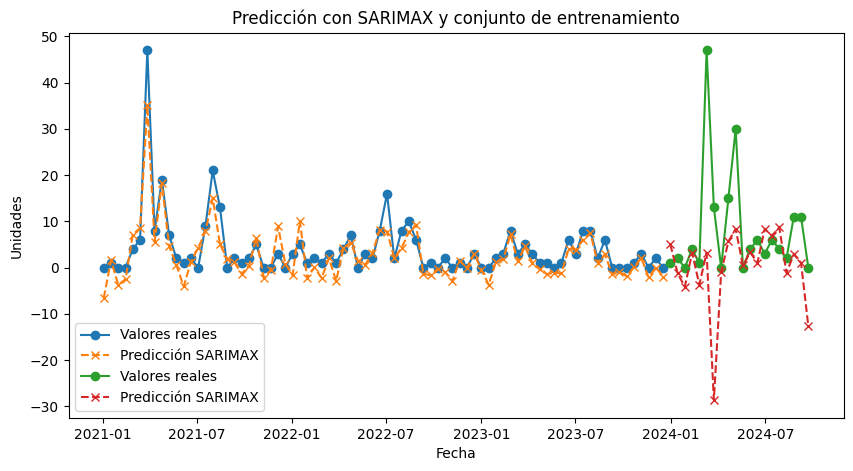

In [62]:
# Definir variables predictoras
X = data_input.drop(columns=["Unidades"])
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

# Entrenar modelo SARIMAX
modelo_sarimax = SARIMAX(y_train, exog=X_train, order=(p, d, q), seasonal_order=(P, D, Q, s))
resultado_sarimax = modelo_sarimax.fit()

# Predicción con variables externas
pred_sarimax_test = resultado_sarimax.forecast(steps=len(y_test), exog=X_test)
pred_sarimax_train= resultado_sarimax.forecast(steps=len(y_train), exog=X_train)

# Evaluación de métricas
mae_test= mean_absolute_error(y_test, pred_sarimax_test)
mse_test = mean_squared_error(y_test, pred_sarimax_test)
rmse_test = np.sqrt(mse)
r2_test = r2_score(y_test, pred_sarimax_test)
mae_train = mean_absolute_error(y_train, pred_sarimax_train)
mse_train = mean_squared_error(y_train, pred_sarimax_train)
rmse_train = np.sqrt(mse)
r2_train = r2_score(y_train, pred_sarimax_train)

print(f"SARIMAX - MÉTRICAS DE ENTRENAMIENTO:\n"
      f"MAE Train: {mae_train:.4f}, MSE Train: {mse_train:.4f}, RMSE Train: {rmse_train:.4f}, R² Train: {r2_train:.4f}\n")

print(f"SARIMAX - MÉTRICAS DE PRUEBA:\n"
      f"MAE Test: {mae_test:.4f}, MSE Test: {mse_test:.4f}, RMSE Test: {rmse_test:.4f}, R² Test: {r2_test:.4f}")

import matplotlib.pyplot as plt



# Gráficos SARIMAX
plt.figure(figsize=(10, 5))
plt.plot(y_train.index, y_train, label="Valores reales", marker="o")
plt.plot(y_train.index, pred_sarimax_train, label="Predicción SARIMAX", linestyle="dashed", marker="x")
plt.plot(y_test.index, y_test, label="Valores reales", marker="o")
plt.plot(y_test.index, pred_sarimax_test, label="Predicción SARIMAX", linestyle="dashed", marker="x")
plt.legend()
plt.title("Predicción con SARIMAX y conjunto de entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.show()



In [63]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "SARIMAX"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics5 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics5


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,SARIMAX,9.461937,2.295521,3.076026,0.774976,234.219864,9.257129,3.076026,-0.798924


## Prophet

12:17:51 - cmdstanpy - INFO - Chain [1] start processing
12:17:52 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\jcasares\AppData\Local\Temp\ipykernel_13160\576309007.py:76: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


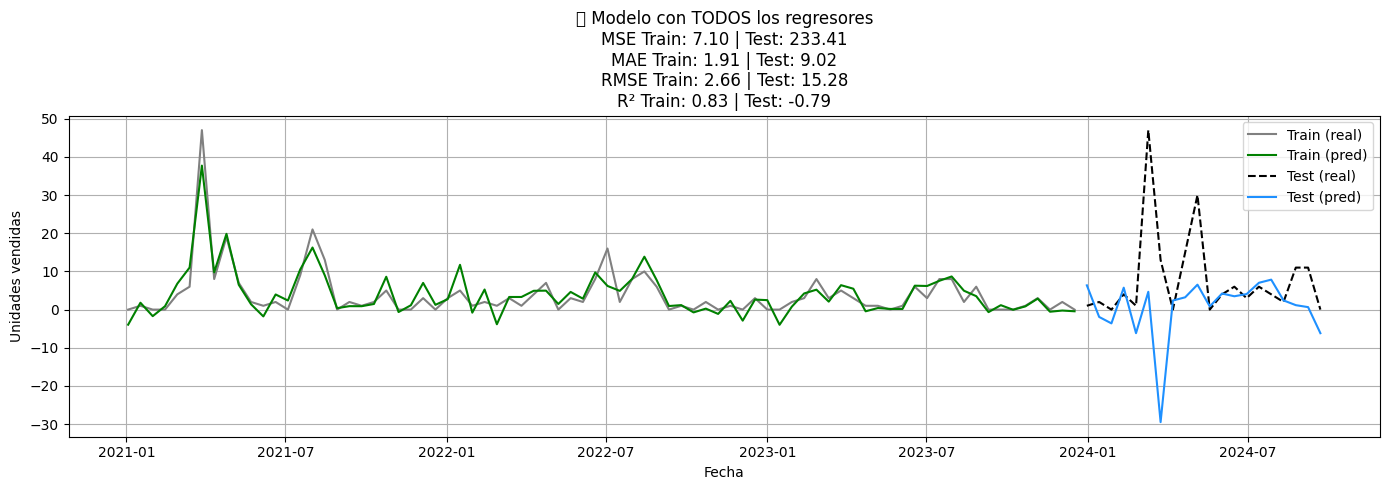

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet #pip install sino la tienes
from sklearn.metrics import mean_absolute_error, mean_squared_error


df=data_input
df = df.rename(columns={"Unidades": "y"})  # Asignar 'y' a las unidades

# Crear la columna 'ds' con las fechas del índice
df["ds"] = df.index  # Mantener las fechas correctamente

# Separar regresores
regresores_clima = [col for col in df.columns if col.startswith('conditions_')]
regresores_producto = [col for col in df.columns if col.startswith('CodigoArticulo_')]
todos_regresores = regresores_clima + regresores_producto

def run_prophet(df, regresores, titulo):
    columnas = ['ds', 'y'] + regresores
    df_model = df[columnas].copy()

    split_index = int(len(df_model) * 0.8)
    df_train = df_model.iloc[:split_index].reset_index(drop=True)
    df_test = df_model.iloc[split_index:].reset_index(drop=True)

    modelo = Prophet()
    for r in regresores:
        modelo.add_regressor(r)

    modelo.fit(df_train)

    forecast_train = modelo.predict(df_train[['ds'] + regresores])
    forecast_test = modelo.predict(df_test[['ds'] + regresores])

    # Métricas
    mse_train = mean_squared_error(df_train['y'], forecast_train['yhat'])
    mae_train = mean_absolute_error(df_train['y'], forecast_train['yhat'])
    rmse_train = np.sqrt(mean_squared_error(df_train['y'], forecast_train['yhat']))
    r2_train = r2_score(df_train['y'], forecast_train['yhat'])
    mae_test = mean_absolute_error(df_test['y'], forecast_test['yhat'])
    rmse_test = np.sqrt(mean_squared_error(df_test['y'], forecast_test['yhat']))
    r2_test = r2_score(df_test['y'], forecast_test['yhat'])
    mse_test = mean_squared_error(df_test['y'], forecast_test['yhat'])

    # Definir el nombre del modelo (puedes modificarlo según corresponda)
    modelo = "Prophet"  # Cambia esto según el modelo que estés evaluando

    # Crear el DataFrame con las métricas
    df_metrics6= pd.DataFrame({
        "Modelo": [modelo],
        "MSE Train": [mse_train],
        "MAE Train": [mae_train],
        "RMSE Train": [rmse_train],
        "R² Train": [r2_train],
        "MSE Test": [mse_test],
        "MAE Test": [mae_test],
        "RMSE Test": [rmse_test],
        "R² Test": [r2_test]
    })

    # Gráfico
    plt.figure(figsize=(14, 5))
    plt.plot(df_train['ds'], df_train['y'], label='Train (real)', color='gray')
    plt.plot(df_train['ds'], forecast_train['yhat'], label='Train (pred)', color='green')
    plt.plot(df_test['ds'], df_test['y'], label='Test (real)', color='black', linestyle='--')
    plt.plot(df_test['ds'], forecast_test['yhat'], label='Test (pred)', color='dodgerblue')
    plt.title(f"{titulo}\n"
          f"MSE Train: {mse_train:.2f} | Test: {mse_test:.2f}\n"
          f"MAE Train: {mae_train:.2f} | Test: {mae_test:.2f}\n"
          f"RMSE Train: {rmse_train:.2f} | Test: {rmse_test:.2f}\n"
          f"R² Train: {r2_train:.2f} | Test: {r2_test:.2f}")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df_metrics6 

# Ejecutar los 4 escenarios
df_metrics6_1=run_prophet(df, todos_regresores, "🔹 Modelo con TODOS los regresores")



12:17:52 - cmdstanpy - INFO - Chain [1] start processing
12:17:53 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\jcasares\AppData\Local\Temp\ipykernel_13160\576309007.py:76: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


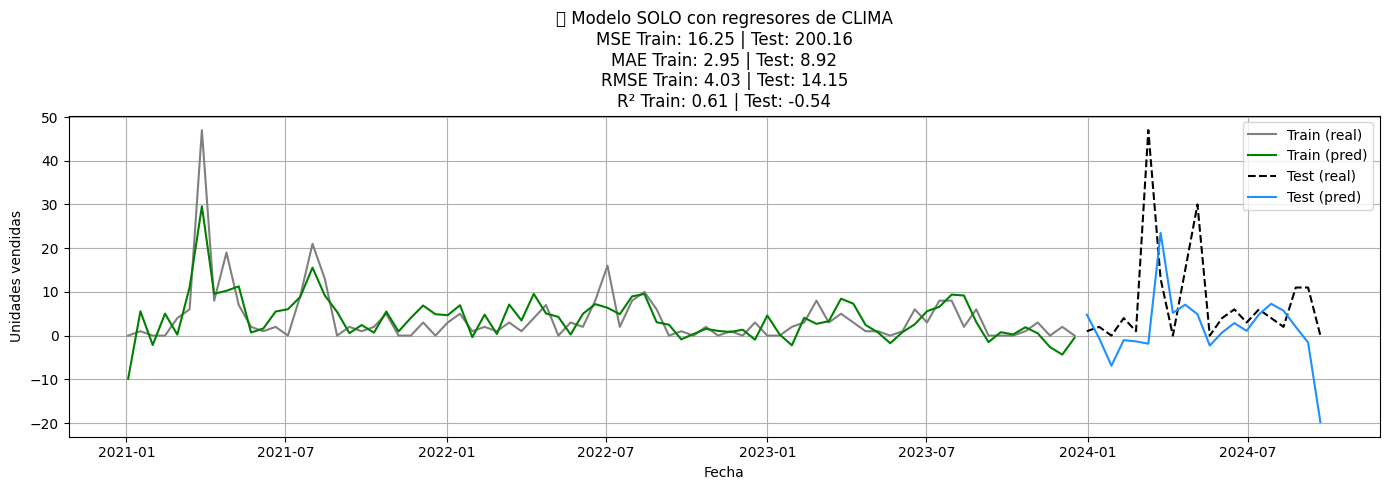

In [65]:
df_metrics6_2=run_prophet(df, regresores_clima, "🔹 Modelo SOLO con regresores de CLIMA")


12:17:53 - cmdstanpy - INFO - Chain [1] start processing
12:17:54 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\jcasares\AppData\Local\Temp\ipykernel_13160\576309007.py:76: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


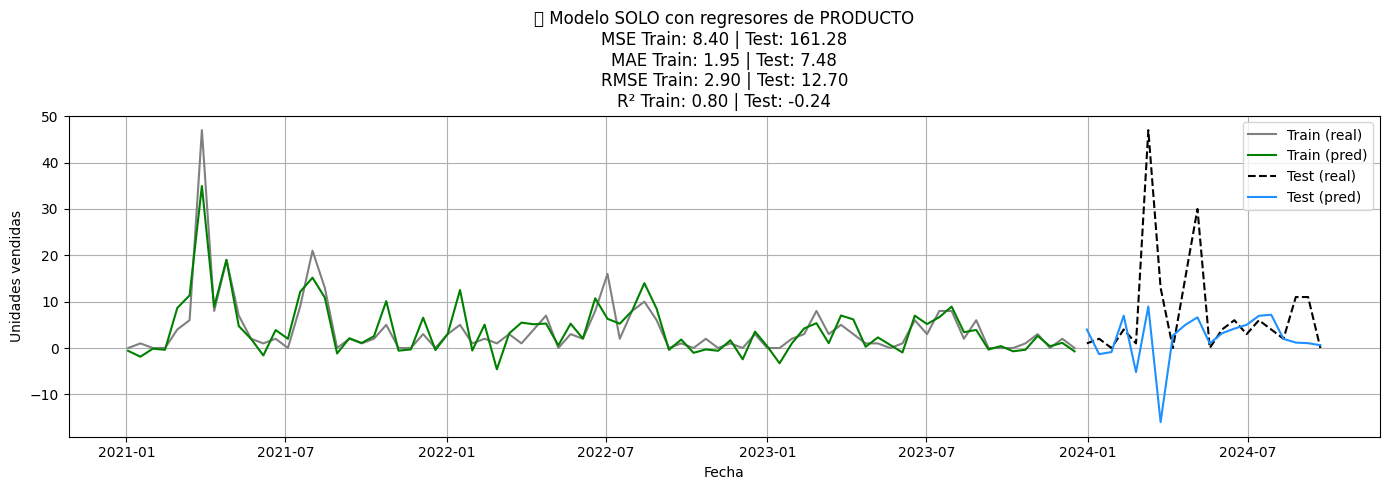

In [66]:
df_metrics6_3=run_prophet(df, regresores_producto, "🔹 Modelo SOLO con regresores de PRODUCTO")


12:17:54 - cmdstanpy - INFO - Chain [1] start processing
12:17:54 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\jcasares\AppData\Local\Temp\ipykernel_13160\576309007.py:76: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jcasares\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


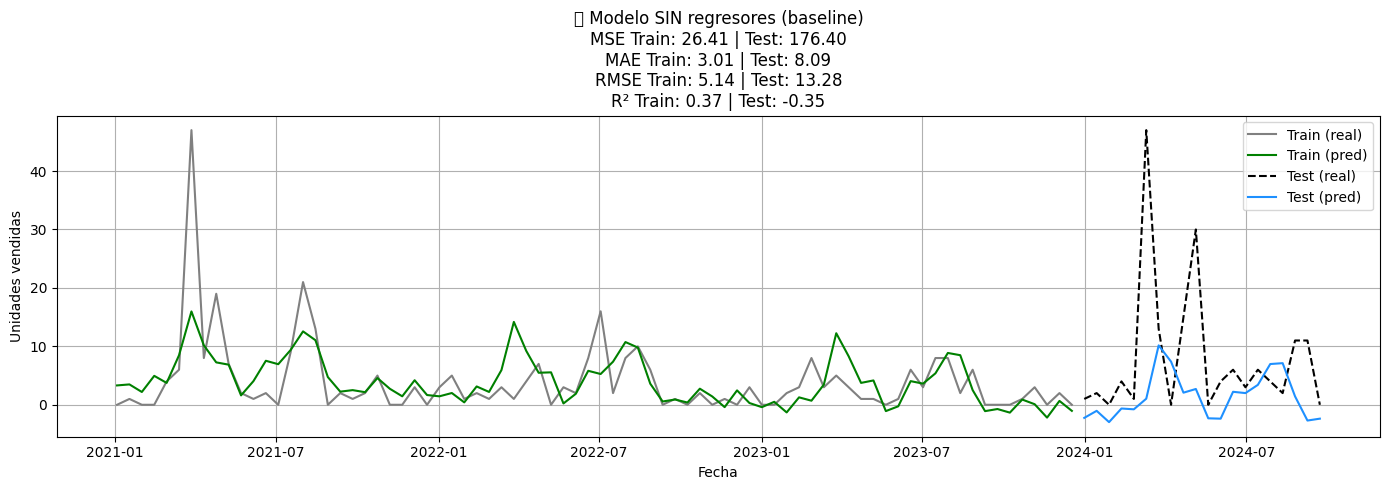

In [67]:
df_metrics6_4= run_prophet(df, [], "🔹 Modelo SIN regresores (baseline)")

In [68]:
import pandas as pd

# Concatenar los DataFrames por filas
df_metrics6 = pd.concat([df_metrics6_1, df_metrics6_2, df_metrics6_3, df_metrics6_4], ignore_index=True)

# Mostrar el resultado
df_metrics6


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,Prophet,7.095720,1.909230,2.663779,0.831250,233.405861,9.024463,15.277626,-0.792672
1,Prophet,16.253179,2.954808,4.031523,0.613467,200.164966,8.919182,14.147967,-0.537365
2,Prophet,8.395950,1.950534,2.897577,0.800328,161.280970,7.482349,12.699644,-0.238717
3,Prophet,26.413475,3.013420,5.139404,0.371835,176.397048,8.092646,13.281455,-0.354816


## Random Forest

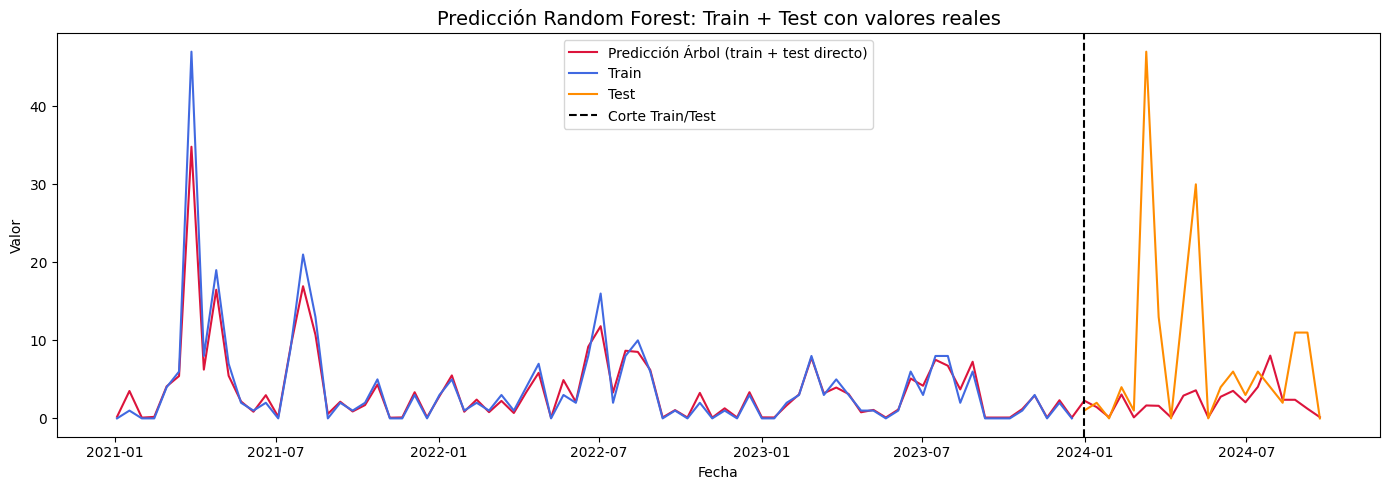

In [69]:
from sklearn.ensemble import RandomForestRegressor

train_size = int(len(df) * 0.8)
train = data_input.iloc[:train_size]
test = data_input.iloc[train_size:]
X_train, y_train = train.drop(columns=['Unidades']), train['Unidades']
X_test, y_test = test.drop(columns=['Unidades']), test['Unidades']






modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=10)
modelo_rf.fit(X_train, y_train)
train_pred = modelo_rf.predict(X_train)
test_pred = modelo_rf.predict(X_test)
indice_predicciones_rf = pd.Series(train.index.tolist() + test.index.tolist())
valores_predichos_rf = np.concatenate([train_pred, test_pred])


plt.figure(figsize=(14, 5))
plt.plot(indice_predicciones_rf, valores_predichos_rf, label='Predicción Árbol (train + test directo)', color='crimson')
plt.plot(df.index[:train_size], y_train, label='Train', color='royalblue')
plt.plot(df.index[train_size:], y_test, label='Test', color='darkorange')
plt.axvline(df.index[train_size], color='black', linestyle='--', label='Corte Train/Test')
plt.title("Predicción Random Forest: Train + Test con valores reales", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
mse_train = mean_squared_error(y_train, train_pred)
mae_train = mean_absolute_error(y_train, train_pred)
rmse_train = rmse = np.sqrt(mse_train)
r2_train = r2_score(y_train, train_pred)
mse_test=mean_squared_error(y_test, test_pred)
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = rmse = np.sqrt(mse_test)
r2_test = r2_score(y_test, test_pred)

In [71]:
import pandas as pd

# Definir el nombre del modelo (puedes modificarlo según corresponda)
modelo = "Random_Forest"  # Cambia esto según el modelo que estés evaluando

# Crear el DataFrame con las métricas
df_metrics7 = pd.DataFrame({
    "Modelo": [modelo],
    "MSE Train": [mse_train],
    "MAE Train": [mae_train],
    "RMSE Train": [rmse_train],
    "R² Train": [r2_train],
    "MSE Test": [mse_test],
    "MAE Test": [mae_test],
    "RMSE Test": [rmse_test],
    "R² Test": [r2_test]
})

df_metrics7


,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,Random_Forest,2.984162,0.778867,1.727473,0.929031,161.540589,6.440538,12.709862,-0.240711


# COMPARACION DE MODELOS

In [75]:
import pandas as pd

# Lista de DataFrames que quieres concatenar
df_list = [df_metrics1, df_metrics2, df_metrics3, df_metrics4, df_metrics5, df_metrics6, df_metrics7]

# Concatenación por filas
df_metrics = pd.concat(df_list, ignore_index=True)

df_metrics.loc[df_metrics["Modelo"] == "Prophet", "Modelo"] = ["Prophet1", "Prophet2", "Prophet3", "Prophet4"]
df_metrics

,Modelo,MSE Train,MAE Train,RMSE Train,R² Train,MSE Test,MAE Test,RMSE Test,R² Test
0,BENCHMARK,62.441558,4.311688,7.901997,-0.473039,266.789474,10.473684,16.333691,-0.985958
1,ARIMA,42.923606,3.446118,3.076026,-0.020808,155.254236,6.754875,3.076026,-0.192429
2,ARIMAX,9.845941,1.809847,3.076026,0.765844,228.180566,8.419796,3.076026,-0.752539
3,SARIMA,57.137227,5.266655,3.076026,-0.358836,186.362436,7.552784,3.076026,-0.431355
4,SARIMAX,9.461937,2.295521,3.076026,0.774976,234.219864,9.257129,3.076026,-0.798924
5,Prophet1,7.095720,1.909230,2.663779,0.831250,233.405861,9.024463,15.277626,-0.792672
6,Prophet2,16.253179,2.954808,4.031523,0.613467,200.164966,8.919182,14.147967,-0.537365
7,Prophet3,8.395950,1.950534,2.897577,0.800328,161.280970,7.482349,12.699644,-0.238717
8,Prophet4,26.413475,3.013420,5.139404,0.371835,176.397048,8.092646,13.281455,-0.354816
9,Random_Forest,2.984162,0.778867,1.727473,0.929031,161.540589,6.440538,12.709862,-0.240711


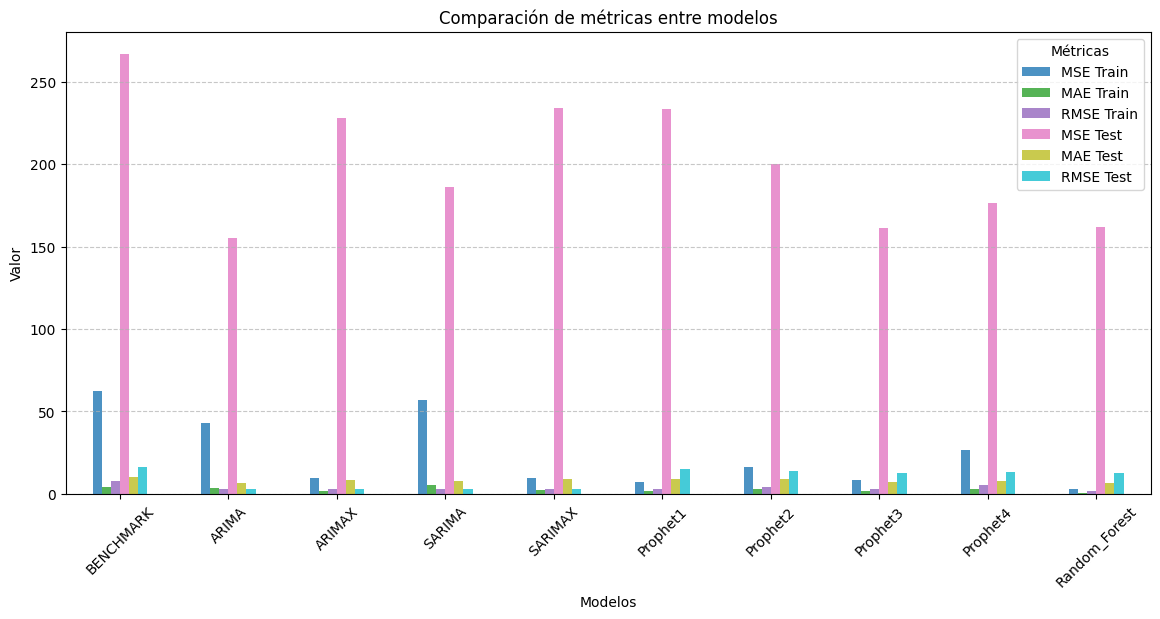

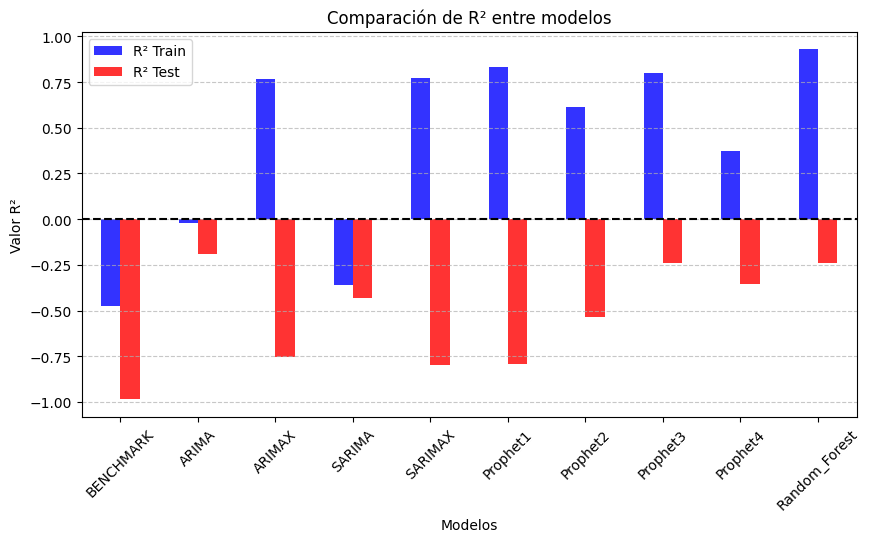

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Métricas a comparar (sin R²)
metrics_general = ["MSE Train", "MAE Train", "RMSE Train", "MSE Test", "MAE Test", "RMSE Test"]
df_general = df_metrics.set_index("Modelo")[metrics_general]

# Gráfico de barras para MSE, MAE y RMSE
df_general.plot(kind="bar", figsize=(14, 6), colormap="tab10", alpha=0.8)
plt.title("Comparación de métricas entre modelos")
plt.xlabel("Modelos")
plt.ylabel("Valor")
plt.legend(title="Métricas")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Gráfico de barras para R²
df_r2 = df_metrics.set_index("Modelo")[["R² Train", "R² Test"]]
df_r2.plot(kind="bar", figsize=(10, 5), color=["blue", "red"], alpha=0.8)
plt.title("Comparación de R² entre modelos")
plt.xlabel("Modelos")
plt.ylabel("Valor R²")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linestyle="--")  # Línea de referencia en 0
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [77]:
import plotly.express as px
import pandas as pd

# Métricas a comparar (sin R²)
metrics_general = ["MSE Train", "MAE Train", "RMSE Train", "MSE Test", "MAE Test", "RMSE Test"]
df_general = df_metrics.melt(id_vars=["Modelo"], value_vars=metrics_general, var_name="Métrica", value_name="Valor")

# Gráfico interactivo de barras
fig = px.bar(df_general, x="Modelo", y="Valor", color="Métrica", barmode="group",
             title="Comparación de métricas entre modelos", labels={"Valor": "Valor Métrica", "Modelo": "Modelos"},
             height=600, width=900)

fig.update_layout(xaxis_tickangle=-45, template="plotly_white")
fig.show()

# Gráfico interactivo de R²
df_r2 = df_metrics.melt(id_vars=["Modelo"], value_vars=["R² Train", "R² Test"], var_name="Métrica", value_name="Valor")

fig_r2 = px.bar(df_r2, x="Modelo", y="Valor", color="Métrica", barmode="group",
                title="Comparación de R² entre modelos", labels={"Valor": "Valor R²", "Modelo": "Modelos"},
                height=500, width=800)

fig_r2.update_layout(xaxis_tickangle=-45, template="plotly_white")
fig_r2.show()